In [40]:
from google.colab import files
import pandas as pd

# Upload the file
uploaded = files.upload()

Saving spamemail.csv to spamemail (2).csv


In [42]:
# Replace 'your_file.csv' with your actual file name
df = pd.read_csv('spamemail.csv')
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [43]:
df.tail()

,text,spam
5729,Subject: re : research and development charges...,0
5730,"Subject: re : receipts from visit jim , than...",0
5731,Subject: re : enron case study update wow ! a...,0
5732,"Subject: re : interest david , please , call...",0
5733,Subject: news : aurora 5 . 2 update aurora ve...,0


In [44]:
df.shape

(5734, 2)

In [45]:
df.columns

Index(['text', 'spam'], dtype='object')

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5734 entries, 0 to 5733
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5730 non-null   object
 1   spam    5728 non-null   object
dtypes: object(2)
memory usage: 89.7+ KB


In [47]:
df.isnull().sum()

,0
text,4
spam,6


In [48]:
df[df.isnull().any(axis=1)]

,text,spam
1380,Subject: from the enron india newsdesk - april...,NaN
1381,NaN,NaN
1382,NaN,NaN
2653,Subject: from the enron india newsdesk - april...,NaN
2654,NaN,NaN
2655,NaN,NaN


In [49]:
df = df.dropna()

In [50]:
print(df.isnull().sum())

text    0
spam    0
dtype: int64


In [51]:
df.dtypes

,0
text,object
spam,object


In [52]:
df = df[df['spam'].isin(['0', '1'])]

In [53]:
print(df['spam'].unique())

['1' '0']


In [54]:
df['spam'] = df['spam'].astype(int)

In [55]:
print(df.shape)

(5726, 2)


In [56]:
df['text'].duplicated().sum()

np.int64(33)

In [57]:
df[df.duplicated(subset=['text'], keep=False)]

,text,spam
1420,"Subject: day off tuesday stinson , i would l...",0
1511,Subject: re : enron weather research good aft...,0
1535,Subject: schedule and more . . dr . kaminski ...,0
1670,"Subject: re : summer work . . jinbaek , this...",0
1752,"Subject: term paper dr . kaminski , attached...",0
...,...,...
5638,Subject: term project : this is the list of p...,0
5670,Subject: june 21 - 22 retail electricity confe...,0
5680,Subject: re : enron weather research good aft...,0
5704,Subject: schedule and more . . dr . kaminski ...,0


In [58]:
df = df.drop_duplicates()

In [59]:
df.duplicated().sum()

np.int64(0)

In [60]:
df.shape

(5693, 2)

In [61]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return text

df['clean_text'] = df['text'].apply(clean_text)

In [62]:
X = df['clean_text']
y = df['spam']

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [64]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()

X_train = tfidf.fit_transform(X_train)
X_test = tfidf.transform(X_test)

In [65]:
print(X_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 488561 stored elements and shape (3985, 31517)>
  Coords	Values
  (0, 27349)	0.021591652982028916
  (0, 15118)	0.05815758404583025
  (0, 28259)	0.024306775200403412
  (0, 14183)	0.1359153796054868
  (0, 20415)	0.11230296453319481
  (0, 31286)	0.20157768448043165
  (0, 6298)	0.2380915601464735
  (0, 8432)	0.09128839614146761
  (0, 14989)	0.10598299282924266
  (0, 6500)	0.08524364403019612
  (0, 25280)	0.09374628503870022
  (0, 17723)	0.0876499093167036
  (0, 28335)	0.08619876131596658
  (0, 3016)	0.05060149638645511
  (0, 7766)	0.1349532569707179
  (0, 8213)	0.13942443193421358
  (0, 24572)	0.13942443193421358
  (0, 17395)	0.08641576468006824
  (0, 15875)	0.030034400159964697
  (0, 28618)	0.08463723868770855
  (0, 10557)	0.11938766358910669
  (0, 26526)	0.12094918621736472
  (0, 15932)	0.11232726234983326
  (0, 27869)	0.10981192734914116
  (0, 20572)	0.06313557065536962
  :	:
  (3984, 20420)	0.0881548721999063
  (3984, 22243)

In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Logistic Regression Model
model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Train Accuracy
train_acc = model.score(X_train, y_train)

# Test Accuracy
test_acc = model.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

# Classification Report
print(classification_report(y_test, y_pred))

# Confusion Matrix
print(confusion_matrix(y_test, y_pred))

Train Accuracy: 0.9952321204516938
Test Accuracy: 0.9759953161592506
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1269
           1       1.00      0.91      0.95       439

    accuracy                           0.98      1708
   macro avg       0.98      0.95      0.97      1708
weighted avg       0.98      0.98      0.98      1708

[[1267    2]
 [  39  400]]


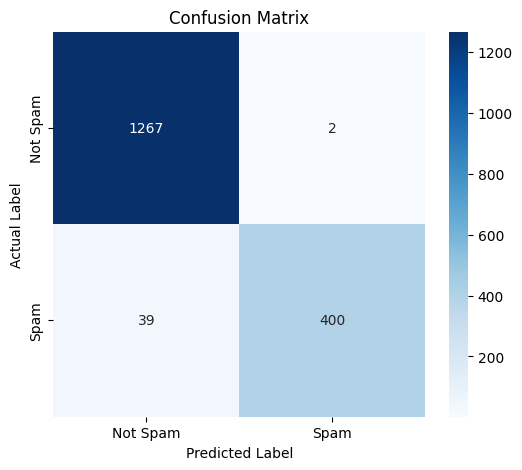

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Not Spam', 'Spam'],
            yticklabels=['Not Spam', 'Spam'])

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()